In [62]:
import pipeline.calculate_metrics
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import gerrychain.grid
import random
from collections import deque
import warnings
import tqdm
random.seed(42)

In [63]:
#renaming graph
#gdf = gpd.read_file("iowa_analysis/goodiowa.shp")

#gdf = gdf.rename(columns={
#    "GEOID": "GISJOIN",
#    "DP0010001": "TOTPOP"
#})

#gdf.to_file("iowa_analysis/goodiowa_renamed.shp")

In [64]:
def clear_metric_caches():
    pipeline.calculate_metrics._angle_1.cache_clear()
    pipeline.calculate_metrics.property_sum.cache_clear()


In [65]:
#Run this in terminal to generate dual graph

#python pipeline/gen_duals.py \
#    "iowa_analysis/goodiowa_renamed.shp" \
#    "iowa_analysis/iowa_graph_orig.json" \
#    "iowa_analysis/iowa_graph.json"

In [66]:
g = gerrychain.Graph.from_json(
    "iowa_analysis/iowa_graph.json"
)

In [67]:
node = next(iter(g.nodes))
print(g.nodes[node])

{'boundary_node': False, 'area': 0.1615409634030013, 'GEOID10': '19169', 'NAMELSAD10': 'Story County', 'FUNCSTAT10': 'A', 'ALAND10': 1483592867.0, 'AWATER10': 2152172.0, 'INTPTLAT10': '+42.0375379', 'INTPTLON10': '-093.4660934', 'TOTPOP': 89542, 'DP0010002': 4803, 'DP0010003': 4462, 'DP0010004': 4197, 'DP0010005': 9609, 'DP0010006': 18846, 'DP0010007': 7445, 'DP0010008': 5324, 'DP0010009': 4205, 'DP0010010': 4132, 'DP0010011': 4508, 'DP0010012': 4827, 'DP0010013': 4720, 'DP0010014': 3519, 'DP0010015': 2509, 'DP0010016': 2001, 'DP0010017': 1611, 'DP0010018': 1331, 'DP0010019': 1493, 'DP0010020': 46412, 'DP0010021': 2487, 'DP0010022': 2286, 'DP0010023': 2141, 'DP0010024': 5022, 'DP0010025': 10639, 'DP0010026': 4126, 'DP0010027': 2862, 'DP0010028': 2232, 'DP0010029': 2080, 'DP0010030': 2190, 'DP0010031': 2361, 'DP0010032': 2369, 'DP0010033': 1752, 'DP0010034': 1192, 'DP0010035': 934, 'DP0010036': 714, 'DP0010037': 535, 'DP0010038': 490, 'DP0010039': 43130, 'DP0010040': 2316, 'DP0010041': 

In [68]:
pos = {
    node: (
        float(g.nodes[node]["INTPTLON10"]),
        float(g.nodes[node]["INTPTLAT10"])
    )
    for node in g.nodes
}

pop = {
    node: g.nodes[node]["TOTPOP"]
    for node in g.nodes
}

sizes = [pop[n] / 100 for n in g.nodes]  # adjust scaling factor

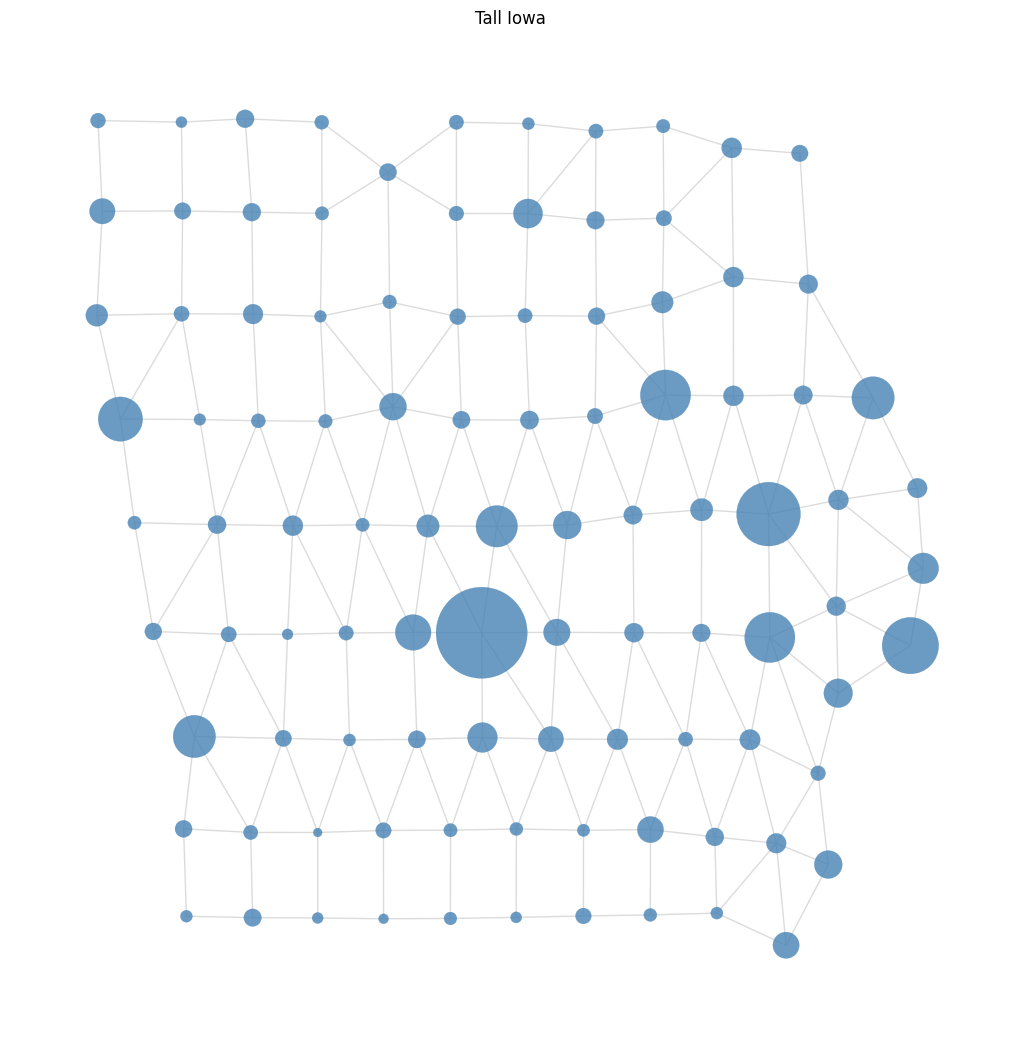

In [69]:
plt.figure(figsize=(10, 10))

nx.draw(
    g,
    pos=pos,
    node_size=sizes,
    node_color="steelblue",
    edge_color="lightgray",
    linewidths=0.2,
    alpha=0.8
)

plt.axis("off")
plt.title("Tall Iowa")

plt.show()

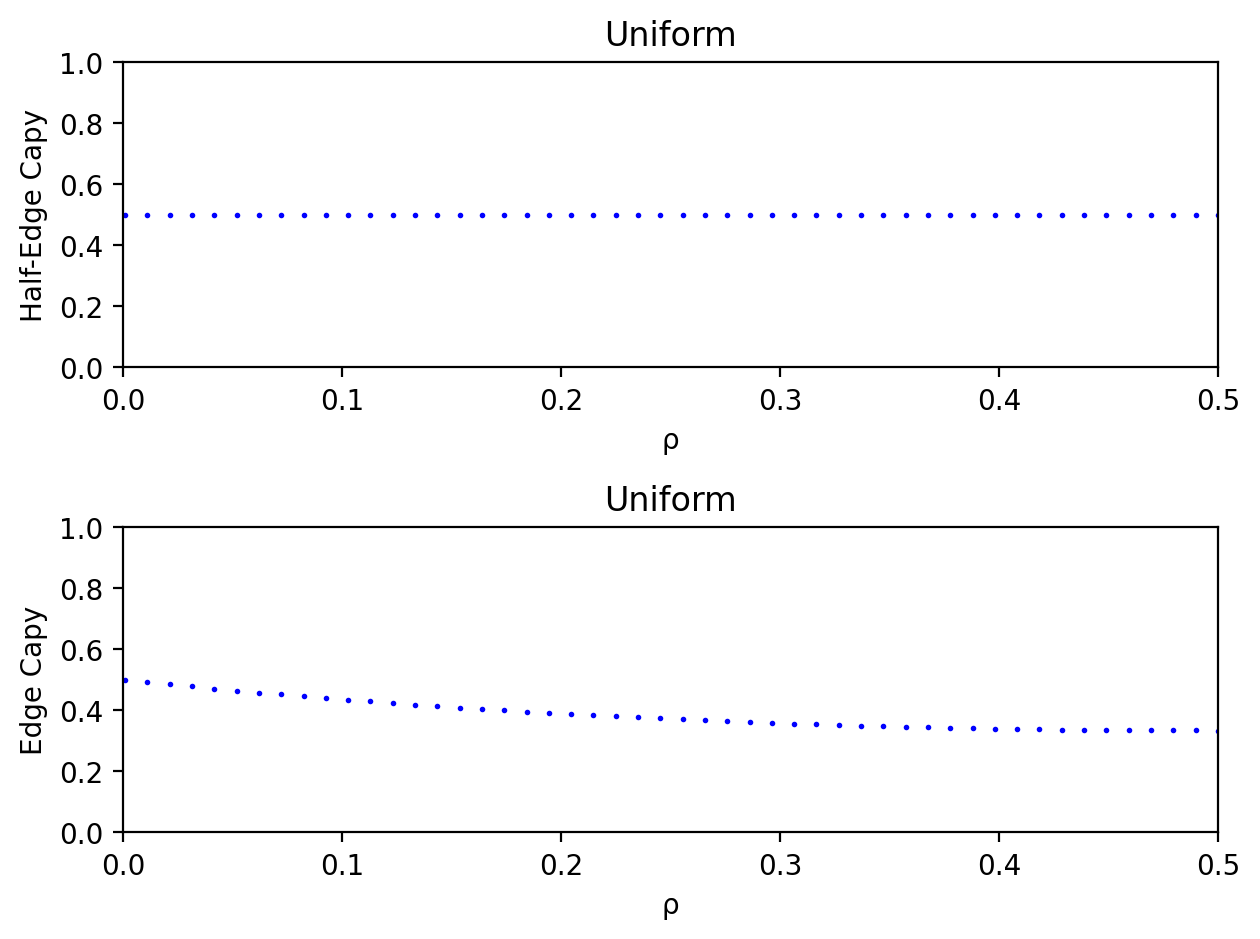

In [70]:
num_rhos = 50

rhos = np.linspace(0.001,0.5, num_rhos)

# data lists for scores
hcaps = np.zeros(num_rhos)
ecaps = np.zeros(num_rhos)

for i in range(num_rhos):
    j=0
    for node in g.nodes():
        g.nodes[node]["x_pop"] = rhos[i]*g.nodes[node]['TOTPOP']
        g.nodes[node]["y_pop"]  = (1-rhos[i])*g.nodes[node]['TOTPOP']
        j += 1
    clear_metric_caches()
    hcaps[i] = pipeline.calculate_metrics.half_edge(g, "x_pop", "y_pop")
    ecaps[i] = pipeline.calculate_metrics.edge(g, "x_pop", "y_pop")
   
fig = plt.figure(dpi=200)
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

ax1.scatter(rhos,hcaps,s=1,c='b')
ax1.set_xlabel(u"\u03C1")
ax1.set_xlim([0,0.5])
ax1.set_ylim([0,1])
ax1.set_ylabel('Half-Edge Capy')
ax1.set_title('Uniform')

ax2.scatter(rhos,ecaps,s=1,c='b')
ax2.set_xlabel(u"\u03C1")
ax2.set_xlim([0,0.5])
ax2.set_ylim([0,1])
ax2.set_ylabel('Edge Capy')
ax2.set_title('Uniform')

plt.tight_layout()
plt.show()

Clusters

In [71]:
def property_sum(graph: gerrychain.Graph, col: str) -> float:
    cummulative = 0
    for node in graph.nodes():
        cummulative += int(graph.nodes[node][col])
    return cummulative

In [72]:

def populate_cluster(G, rho, seed=None):
    """
    Build a connected X-cluster whose total population is ~x_pop_fraction of total.
    X nodes: x_pop = TOTPOP, y_pop = 0
    Y nodes: x_pop = 0, y_pop = TOTPOP
    """

    nodes = list(G.nodes())

    if seed is None:
        seed = random.choice(nodes)

    # total population in graph
    total_pop = property_sum(G, "TOTPOP")
    target_x_pop = rho * total_pop

    x_nodes = set([seed])
    queue = deque([seed])

    current_x_pop = G.nodes[seed].get("TOTPOP", 0)

    while queue and current_x_pop < target_x_pop:
        u = queue.popleft()

        neighbors = list(G.neighbors(u))
        random.shuffle(neighbors)

        for v in neighbors:
            if v not in x_nodes:
                x_nodes.add(v)
                queue.append(v)

                current_x_pop += G.nodes[v].get("TOTPOP", 0)

                if current_x_pop >= target_x_pop:
                    break

    # assign populations
    for n in G.nodes():
        pop = G.nodes[n].get("TOTPOP", 0)

        if n in x_nodes:
            G.nodes[n]["x_pop"] = pop
            G.nodes[n]["y_pop"] = 0
        else:
            G.nodes[n]["x_pop"] = 0
            G.nodes[n]["y_pop"] = pop
        
    real_rho =  current_x_pop / total_pop
    
    clear_metric_caches()
    return G, real_rho

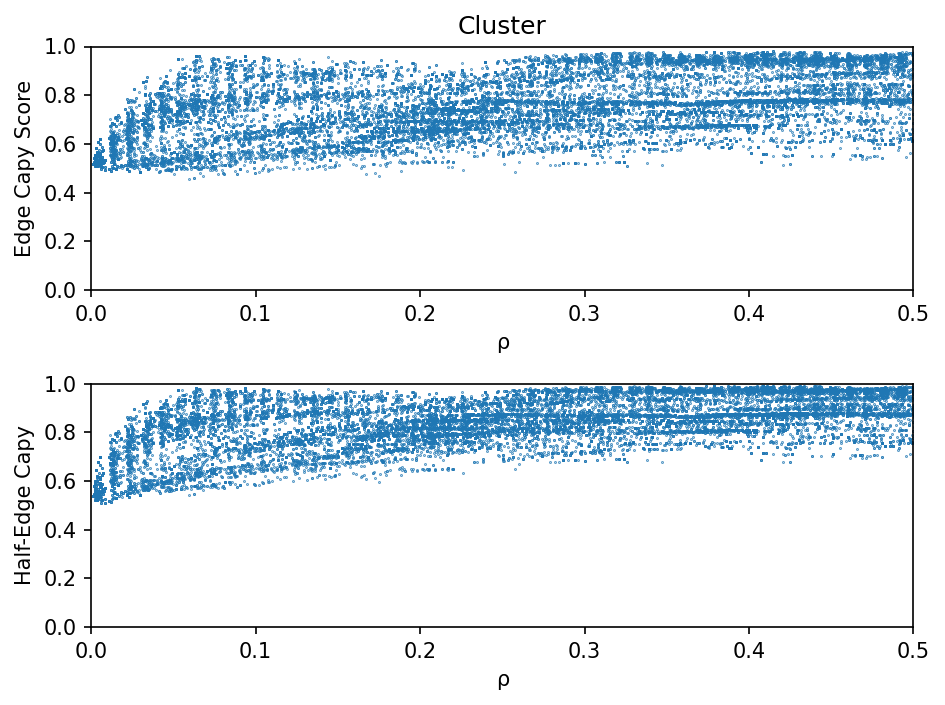

In [73]:
num_samples = 500
num__rhos = 100
fig = plt.figure(dpi=150)
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

ecaps = []
hcaps = []
real_rhos = []

for _ in range(num_samples):
    for rho in np.linspace(.001, .5, num_rhos):
        for node in g.nodes():
            g.nodes[node]["x_pop"] = 0
            g.nodes[node]["y_pop"] = 0

        graph, rho = populate_cluster(g, rho)
        ecaps.append(pipeline.calculate_metrics.edge(graph, "x_pop", "y_pop"))
        hcaps.append(pipeline.calculate_metrics.half_edge(graph, "x_pop", "y_pop"))
        real_rhos.append(rho)
        





ax1.set_xlabel(u'\u03C1')
ax1.set_ylabel('Edge Capy Score')
ax1.set_title('Cluster')
ax1.set_ylim([0,1])
ax1.set_xlim([0,0.5])
ax1.scatter(real_rhos, ecaps, s =.1)

ax2.set_xlabel(u'\u03C1')
ax2.set_ylabel('Half-Edge Capy')
ax2.set_ylim([0,1])
ax2.set_xlim([0,0.5])
ax2.scatter(real_rhos, hcaps, s = .1)

plt.tight_layout()
plt.show()

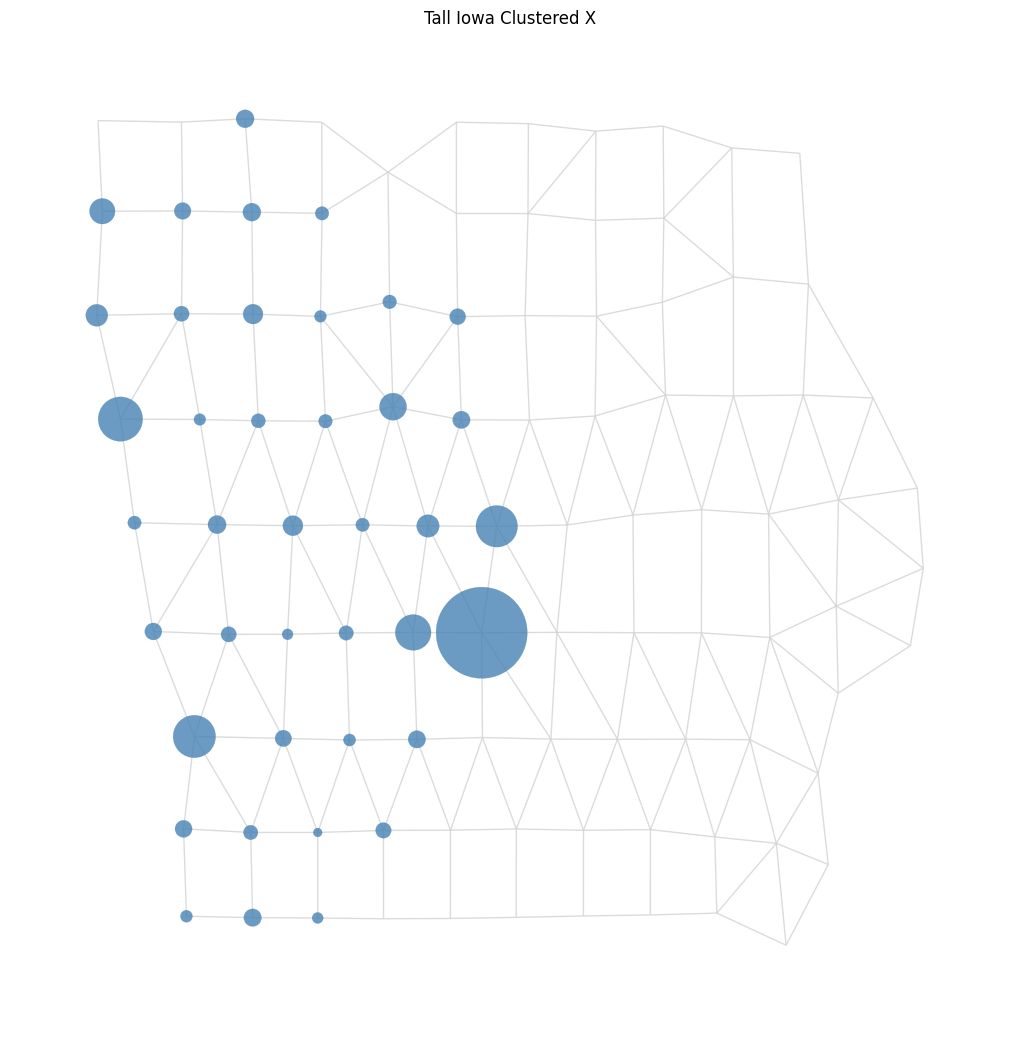

In [74]:
g, rho = populate_cluster(g, .4)

pos = {
    node: (
        float(g.nodes[node]["INTPTLON10"]),
        float(g.nodes[node]["INTPTLAT10"])
    )
    for node in g.nodes
}

pop = {
    node: g.nodes[node]["x_pop"]
    for node in g.nodes
}

sizes = [pop[n] / 100 for n in g.nodes]  # adjust scaling factor
plt.figure(figsize=(10, 10))

nx.draw(
    g,
    pos=pos,
    node_size=sizes,
    node_color="steelblue",
    edge_color="lightgray",
    linewidths=0.2,
    alpha=0.8
)

plt.axis("off")
plt.title("Tall Iowa Clustered X")

plt.show()

Isolates

In [75]:
def valid_isolated_config(g, column):
    nodes_in_cluster = []
    i=0
    for node in g.nodes():
        if g.nodes[node][column] >0:
            nodes_in_cluster.append(node)
        i+=1
    
    # should have as many connected components as there are nonzero entries
    if nx.number_connected_components(g.subgraph(nodes_in_cluster)) == np.count_nonzero([g.nodes[node]["x_pop"] for node in g.nodes]):
        return True
    else:
        return False
    

In [76]:
def make_random_isolated_config(g):
    # reset populations
    for node in g.nodes():
        g.nodes[node]["x_pop"] = 0
        g.nodes[node]["y_pop"] = g.nodes[node]["TOTPOP"]

    selected = set()
    blocked = set()

    nodes = list(g.nodes())
    random.shuffle(nodes)

    for node in nodes:
        if node in blocked:
            continue

        selected.add(node)
        blocked.add(node)
        blocked.update(g.neighbors(node))

        g.nodes[node]["x_pop"] = g.nodes[node]["TOTPOP"]
        g.nodes[node]["y_pop"] = 0

    for node in g.nodes():
        g.nodes[node]["y_pop"] = g.nodes[node]["TOTPOP"] - g.nodes[node]["x_pop"]

    clear_metric_caches()
    return g

In [77]:
def smallify(g, rho):
    g = make_random_isolated_config(g)
    total_pop = property_sum(g, "TOTPOP")

    nodes = list(g.nodes())
    random.shuffle(nodes)

    for node in nodes:
        current_rho = property_sum(g, "x_pop") / total_pop
        if current_rho <= rho:
            clear_metric_caches()
            return g, current_rho

        if g.nodes[node]["x_pop"] > 0:
            g.nodes[node]["y_pop"] = g.nodes[node]["TOTPOP"]
            g.nodes[node]["x_pop"] = 0

    clear_metric_caches()
    return g, property_sum(g, "x_pop") / total_pop

In [78]:

total_pop = property_sum(g, "TOTPOP")

real_rhos = []
ecaps = []
hcaps = []



num_samples = 500
num_rhos = 100
for _ in range(num_samples):
    for rho in np.linspace(0.01, .5, num_rhos):
        g = make_random_isolated_config(g)

        g_, real_rho = smallify(g, rho)

        if not valid_isolated_config(g_, "x_pop"):
            print("invalid configuration")
            continue

        if property_sum(g_, "x_pop") == 0 or property_sum(g_, "y_pop") == 0:
            print("0 pop")
            continue

        real_rhos.append(real_rho)
        ecaps.append(pipeline.calculate_metrics.edge(g_, "x_pop", "y_pop"))
        hcaps.append(pipeline.calculate_metrics.half_edge(g_, "x_pop", "y_pop"))

0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 pop
0 po

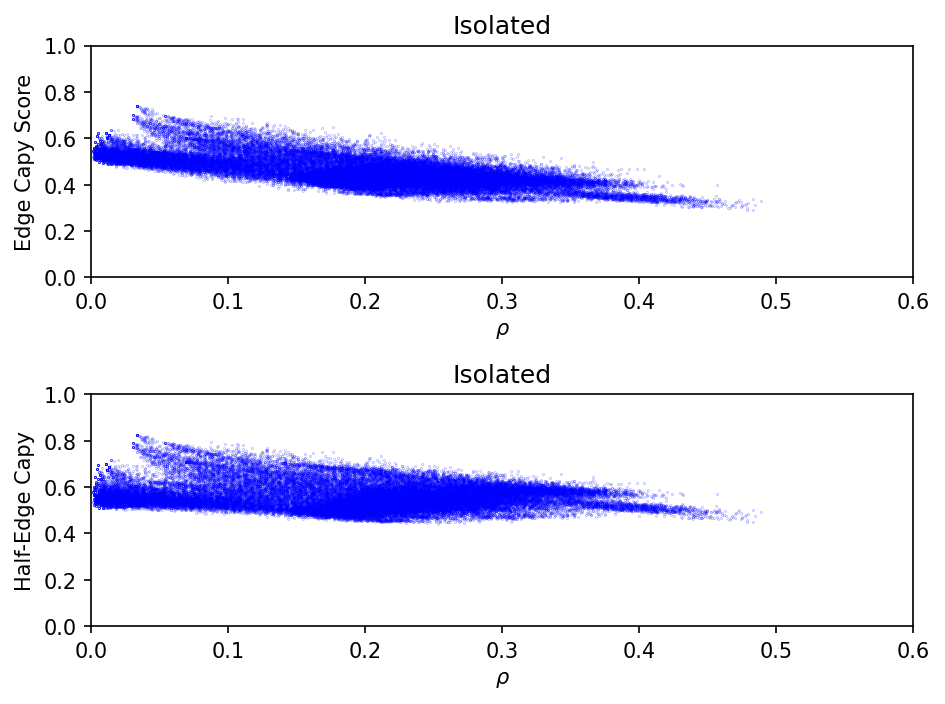

In [79]:
fig = plt.figure(dpi=150)
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)

ax1.scatter(real_rhos, ecaps, c="b", s=.01)
ax2.scatter(real_rhos, hcaps, c="b", s=.01)

ax1.set_xlabel(r"$\rho$")
ax1.set_ylabel("Edge Capy Score")
ax1.set_title("Isolated")
ax1.set_ylim([0, 1])
ax1.set_xlim([0, 0.6])

ax2.set_xlabel(r"$\rho$")
ax2.set_ylabel("Half-Edge Capy")
ax2.set_title("Isolated")
ax2.set_ylim([0, 1])
ax2.set_xlim([0, 0.6])

plt.tight_layout()
plt.show()

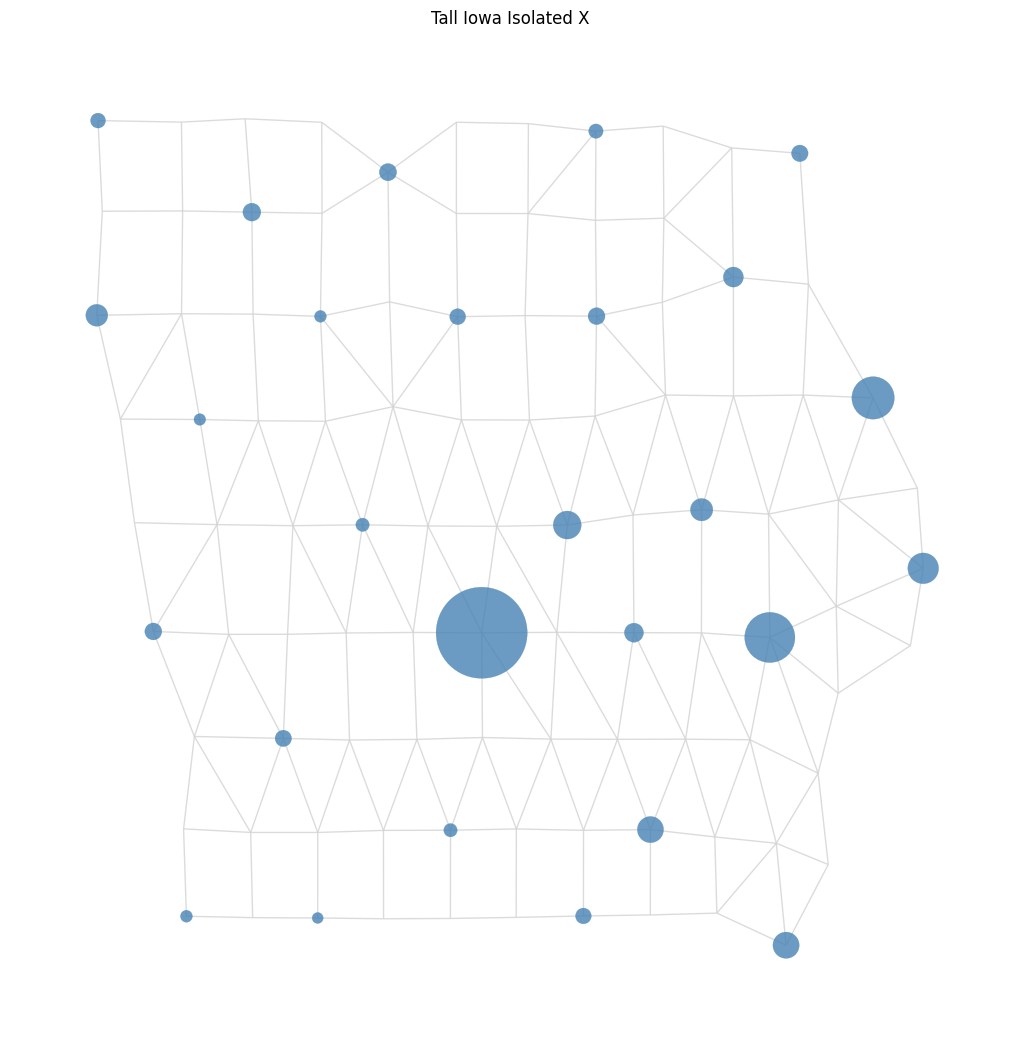

In [80]:
g = make_random_isolated_config(g)

pos = {
    node: (
        float(g.nodes[node]["INTPTLON10"]),
        float(g.nodes[node]["INTPTLAT10"])
    )
    for node in g.nodes
}

pop = {
    node: g.nodes[node]["x_pop"]
    for node in g.nodes
}

sizes = [pop[n] / 100 for n in g.nodes]  # adjust scaling factor
plt.figure(figsize=(10, 10))

nx.draw(
    g,
    pos=pos,
    node_size=sizes,
    node_color="steelblue",
    edge_color="lightgray",
    linewidths=0.2,
    alpha=0.8
)

plt.axis("off")
plt.title("Tall Iowa Isolated X")

plt.show()


In [81]:
g = make_random_isolated_config(g)
Ms = pipeline.calculate_metrics.moran(g, "x_pop", "TOTPOP")
A, P, L, M = pipeline.calculate_metrics.make_adj_weights(g)

/Users/samstephenson/Downloads/capy-bara/pipeline/calculate_metrics.py:303: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = scipy.sparse.diags(degrees)
/Users/samstephenson/Downloads/capy-bara/pipeline/calculate_metrics.py:345: RuntimeWarning: divide by zero encountered in scalar divide
  morans[f"moran_{name}"] = (len(graph) / S0) * numerator / denominator


In [82]:
Ms

{'moran_A': np.float64(-0.3966613672496032),
 'moran_P': np.float64(-0.4352240896358549),
 'moran_L': np.float64(inf),
 'moran_M': np.float64(-0.26388926538357305)}

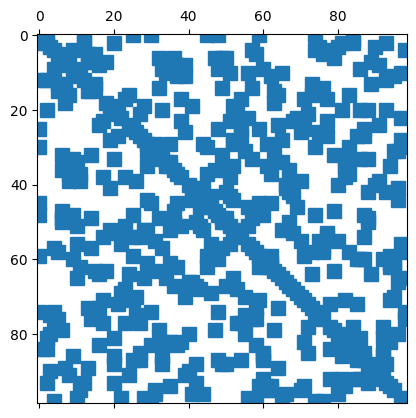

In [83]:
plt.spy(M)

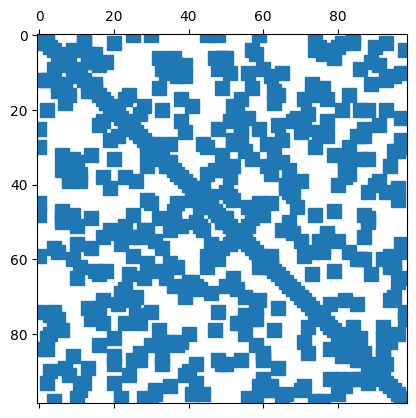

In [84]:
plt.spy(L)

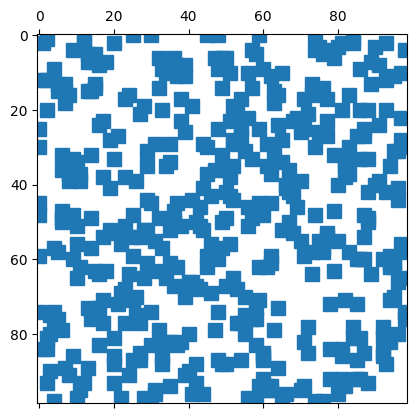

In [85]:
plt.spy(P)

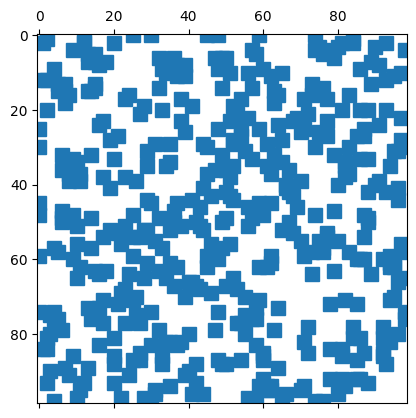

In [86]:
plt.spy(A)

In [87]:
import scipy
nodes = list(g.nodes())
degrees = np.array([g.degree(n) for n in nodes])    
D = scipy.sparse.diags(degrees)

/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_9365/3321107192.py:4: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = scipy.sparse.diags(degrees)


In [88]:
inv_degrees = np.zeros_like(degrees, dtype=float)
mask = degrees > 0
inv_degrees[mask] = 1 / degrees[mask]
D_inv = scipy.sparse.diags(inv_degrees)

In [89]:
degrees

array([6, 3, 6, 3, 5, 4, 6, 4, 4, 5, 6, 4, 3, 5, 5, 5, 5, 5, 2, 3, 6, 3,
       3, 5, 3, 6, 3, 5, 4, 5, 5, 4, 5, 5, 4, 6, 4, 5, 5, 5, 3, 4, 4, 3,
       4, 5, 3, 3, 6, 6, 6, 5, 6, 3, 5, 4, 5, 5, 5, 6, 6, 5, 7, 4, 4, 5,
       3, 3, 3, 2, 4, 5, 3, 4, 5, 3, 6, 5, 3, 4, 4, 5, 5, 4, 4, 5, 6, 6,
       6, 3, 2, 3, 5, 5, 6, 5, 5, 5, 5])

In [90]:
inv_degrees

array([0.16666667, 0.33333333, 0.16666667, 0.33333333, 0.2       ,
       0.25      , 0.16666667, 0.25      , 0.25      , 0.2       ,
       0.16666667, 0.25      , 0.33333333, 0.2       , 0.2       ,
       0.2       , 0.2       , 0.2       , 0.5       , 0.33333333,
       0.16666667, 0.33333333, 0.33333333, 0.2       , 0.33333333,
       0.16666667, 0.33333333, 0.2       , 0.25      , 0.2       ,
       0.2       , 0.25      , 0.2       , 0.2       , 0.25      ,
       0.16666667, 0.25      , 0.2       , 0.2       , 0.2       ,
       0.33333333, 0.25      , 0.25      , 0.33333333, 0.25      ,
       0.2       , 0.33333333, 0.33333333, 0.16666667, 0.16666667,
       0.16666667, 0.2       , 0.16666667, 0.33333333, 0.2       ,
       0.25      , 0.2       , 0.2       , 0.2       , 0.16666667,
       0.16666667, 0.2       , 0.14285714, 0.25      , 0.25      ,
       0.2       , 0.33333333, 0.33333333, 0.33333333, 0.5       ,
       0.25      , 0.2       , 0.33333333, 0.25      , 0.2    

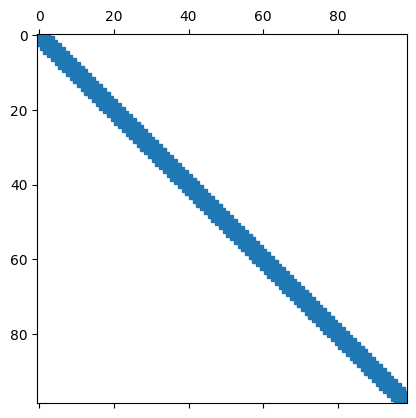

In [91]:
plt.spy(D)

In [92]:
matrix = np.array([[10, 20, 30], 
                   [40, 50, 60],
                   [5, 15, 25]])
matrix.sum()

np.int64(255)

In [93]:
matrix = np.array([[0, 0, 1], 
                   [1, 0, 1],
                   [1, 1, 0]])

degrees = np.array([1, 2, 2])

D = scipy.sparse.diags(degrees)
inv_degrees = np.zeros_like(degrees, dtype=float)
mask = degrees > 0
inv_degrees[mask] = 1 / degrees[mask]
D_inv = scipy.sparse.diags(inv_degrees)

/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_9365/3229805352.py:7: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  D = scipy.sparse.diags(degrees)


In [94]:
L = matrix - D

In [95]:
L.sum()

np.float64(0.0)